In [2]:
import numpy as np
import scipy as sp
import krylov as kr
import ham_generator as gen
import matplotlib.pyplot as plt
import networkx as nx

# Real triangle with initial superposition of two sites

$$\ket{\psi_0} = \text{cos}\left(\frac{\theta}{2}\right)\ket{0} + e^{i\varphi}\text{sin}\left(\frac{\theta}{2}\right)\ket{1} $$

$$\ket{\psi_0} = c_0(\theta,\varphi)\ket{E_0} + c_+(\theta,\varphi)\ket{E_+} $$

with: $$ c_0(\theta,\varphi) = \frac{1}{\sqrt{3}}\left (\text{cos}\left(\frac{\theta}{2}\right) + e^{i\varphi}\text{sin}\left(\frac{\theta}{2}\right)\right )  $$ ,

$$c_+(\theta,\varphi) = \sqrt{\frac{2}{3}}\sqrt{1+\text{cos}\left(\frac{\theta}{2}\right)\text{sin}\left(\frac{\theta}{2}\right)\left(\text{cos}(\varphi+2\pi/3)+\text{cos}(\varphi+4\pi/3)  \right)} $$

The only relevant Lanczos coefficients are $ a_0 $ and $ b_1 $, which evaluate to:

\begin{equation}
    a_0(\theta, \phi) = \text{sin}(\theta)\text{cos}(\varphi),
\end{equation}
and
\begin{equation}
    b_1(\theta, \phi) = \sqrt{|c_0|^2(2-a_0)^2+|c_+|^2(1+a_0)^2}
\end{equation}

The infinite time-averaged complexity is:
\begin{equation}
    \bar{C}(\theta, \phi) = \frac{1}{b_1^2}\left ( |c_0|^4(2-a_0)^2 + |c_+|^4(1+a_0)^2 \right)
\end{equation}

In [16]:
#definition of analytical solutions
#C0
def c_0(theta1=0., phi1=0., theta2=0., phi2=0.):
    norm = 1./np.sqrt(3)
    c1 = np.cos(theta1/2.)
    s1 = np.sin(theta1/2.)
    c2 = np.cos(theta2/2.)
    s2 = np.sin(theta2/2.)
    phase1 = np.exp(phi1*1.j)
    phase2 = np.exp(phi2*1.j)
    return norm*(c1 + phase1*s1*c2 + phase2*s1*s2)

#C+
def c_plus(theta1=0., phi1=0., theta2=0, phi2=0):
    norm = np.sqrt(2./3.)
    
    c1 = np.cos(theta1/2.)
    s1 = np.sin(theta1/2.)
    c2 = np.cos(theta2/2.)
    s2 = np.sin(theta2/2.)

    shift = 2.*np.pi/3.

    c1_shifted = np.cos(phi1+shift)
    c1_shifted2 = np.cos(phi1+2*shift)
    c2_shifted = np.cos(phi2+shift)
    c2_shifted2 = np.cos(phi2+2*shift)
    cdiff_shifted = np.cos(phi1-phi2 + shift)
    cdiff_shifted2 = np.cos(phi1-phi2 + 2*shift)

    body = 1 + c1*s1*c2*(c1_shifted+c1_shifted2) + c1*s1*s2*(c2_shifted+c2_shifted2) + (s1**2)*s2*c2*(cdiff_shifted+cdiff_shifted2)

    return norm*np.sqrt(body)

#a0
def a_0(theta1=0., phi1=0., theta2=0., phi2=0.):
    first = np.abs(c_0(theta1, phi1, theta2, phi2))**2
    second = np.abs(c_plus(theta1, phi1, theta2, phi2))**2
    return 2*first - second

#b1
def b_1(theta1=0., phi1=0., theta2=0., phi2=0.):
    first = (np.abs(c_0(theta1, phi1, theta2, phi2))*(2.-a_0(theta1, phi1, theta2, phi2)))**2
    second = (np.abs(c_plus(theta1, phi1, theta2, phi2))*(1.+a_0(theta1, phi1, theta2, phi2)))**2
    return np.sqrt(first+second)

#complexity
def c_bar(theta1=0., phi1=0., theta2=0., phi2=0.):
    norm = 1./(b_1(theta1, phi1, theta2, phi2)**2)
    first = (np.abs(c_0(theta1, phi1, theta2, phi2))**4)*(2.-a_0(theta1, phi1, theta2, phi2))**2
    second = (np.abs(c_plus(theta1, phi1, theta2, phi2))**4)*(1.+a_0(theta1, phi1, theta2, phi2))**2
    return norm*(first+second)


In [11]:
n_thetas = 1000
n_phis = 1000

thetas = np.linspace(start=0.,stop=np.pi, num=n_thetas)
phis = np.linspace(start=0., stop=2*np.pi, num=n_phis)

#theta_phis = np.array([[(theta, phi) for phi in phis] for theta in thetas])

a_0s= np.array([[a_0(theta, phi) for theta in thetas] for phi in phis])
#print(a_0s[:,1])

## $a_0$ as a function of $\theta$ and $\phi$

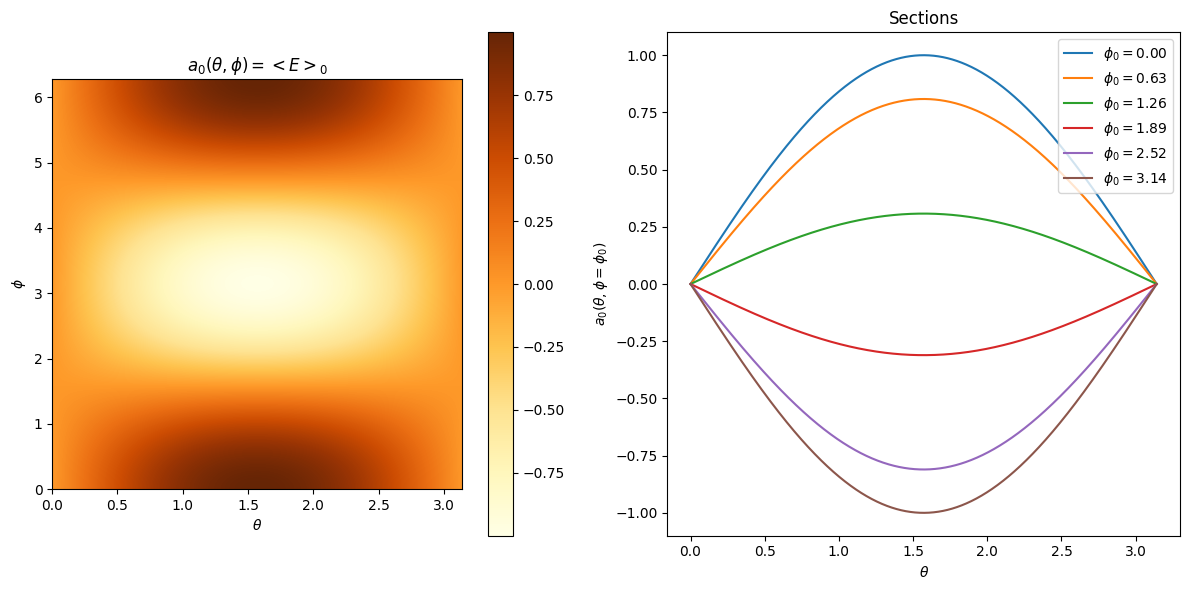

In [17]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

Z = a_0s

im = axx[0].imshow(Z, extent=[thetas[0], thetas[-1], phis[0], phis[-1]], origin='lower', cmap='YlOrBr')
cbr = fig.colorbar(im, ax=axx[0])
axx[0].set_aspect(0.5)
axx[0].set_xlabel(r'$\theta$')
axx[0].set_ylabel(r'$\phi$')
axx[0].set_title(r'$a_0(\theta, \phi)= < E >_0$')

for i in range(6):
    axx[1].plot(thetas, a_0s[100*i,:], label=f"$\phi_0=${format(phis[100*i], '.2f')}")
axx[1].set_xlabel(r'$\theta$')
axx[1].set_ylabel(r'$a_0(\theta, \phi=\phi_0)$')
axx[1].set_title(r'Sections')
axx[1].legend()

plt.show()

## $\bar{C}$ as a function of $\theta$ and $\phi$

\begin{equation}
    \bar{C}(\theta, \phi) = \frac{1}{b_1^2}\left ( |c_0|^4(2-a_0)^2 + |c_+|^4(1+a_0)^2 \right)
\end{equation}

\begin{equation}
    a_0(\theta, \phi) = \text{sin}(\theta)\text{cos}(\varphi)
\end{equation}

In [18]:
n_thetas = 1000
n_phis = 1000

thetas = np.linspace(start=0.,stop=np.pi, num=n_thetas)
phis = np.linspace(start=0., stop=2*np.pi, num=n_phis)

#theta_phis = np.array([[(theta, phi) for phi in phis] for theta in thetas])

c_bars= np.array([[c_bar(theta, phi) for theta in thetas] for phi in phis])
#print(a_0s[:,1])

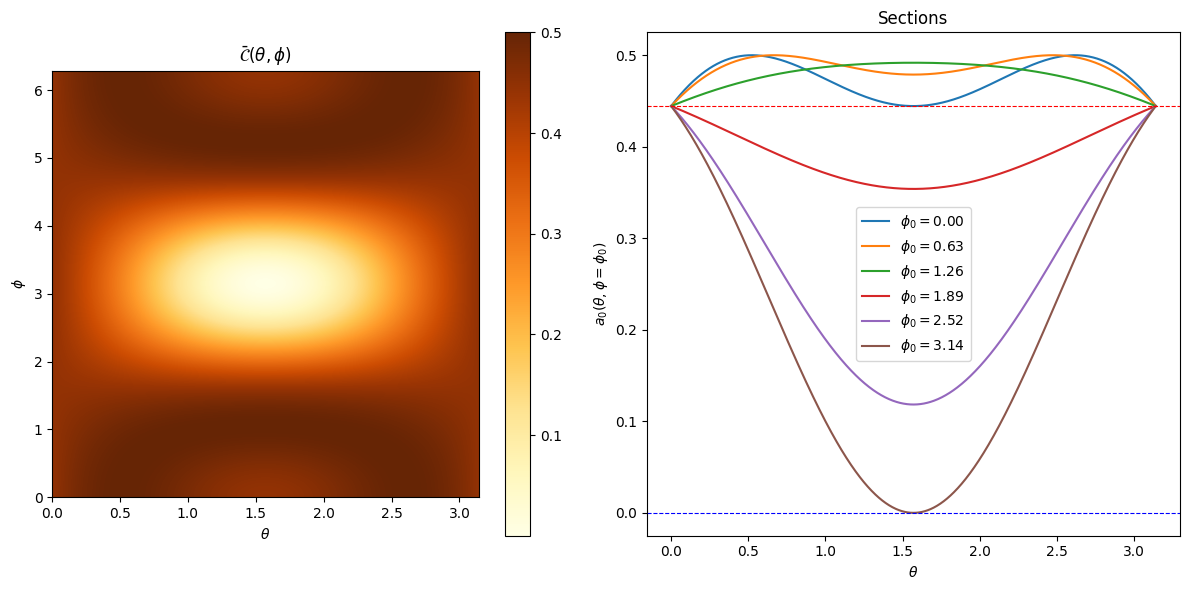

In [21]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

Z = c_bars

im = axx[0].imshow(Z, extent=[thetas[0], thetas[-1], phis[0], phis[-1]], origin='lower', cmap='YlOrBr')
cbr = fig.colorbar(im, ax=axx[0])
axx[0].set_aspect(0.5)
axx[0].set_xlabel(r'$\theta$')
axx[0].set_ylabel(r'$\phi$')
axx[0].set_title(r'$\bar{\mathcal{C}}(\theta, \phi)$')

for i in range(6):
    axx[1].plot(thetas, c_bars[100*i,:], label=f"$\phi_0=${format(phis[100*i], '.2f')}")
axx[1].axhline(y=c_bars[0,0], linestyle='--', color='r', linewidth=0.8)
axx[1].axhline(y=0., linestyle='--', color='b', linewidth=0.8)
axx[1].set_xlabel(r'$\theta$')
axx[1].set_ylabel(r'$a_0(\theta, \phi=\phi_0)$')
axx[1].set_title(r'Sections')
axx[1].legend()

plt.show()

# Superposition of ALL sites (general qutrit)

\begin{equation*}
    \ket{\psi_0} = \text{cos}\left ( \frac{\theta_1}{2} \right ) \ket{0} 
    + e^{i\varphi_1} \text{sin}\left ( \frac{\theta_1}{2} \right ) \text{cos}\left ( \frac{\theta_2}{2} \right ) \ket{1}
    + e^{i\varphi_2} \text{sin}\left ( \frac{\theta_1}{2} \right ) \text{sin}\left ( \frac{\theta_2}{2} \right ) \ket{2};
\end{equation*}

\begin{equation*}
    \ket{\psi_0} = \alpha_0 \ket{E_0} + \alpha_+ \ket{E_+}.
\end{equation*}

Notice that $\ket{E_+}$ is different from the one defined for the qubit: its definition is always chosen such that $\ket{\psi_0}$ is orthogonal to the other basis vector of the eigenspace $\ket{E_+}$ belongs to.

The coefficients are:

\begin{equation*}
    \alpha_0 = \frac{1}{\sqrt{3}} \left ( c_1 + s_1c_2 e^{i\varphi_1} + s_1s_2 e^{i\varphi_2 } \right ),
\end{equation*}

   
\begin{align*}
    \alpha_+ = \sqrt{\frac{2}{3}} \sqrt{1 + c_1s_1c_2 f(\varphi_1) +
               c_1s_1s_2 f(\varphi_2) + 
               s_1^2c_2s_2 f(\varphi_1 - \varphi_2) }.
\end{align*}

where $ f(\varphi) = \text{cos}(\varphi+2\pi/3)+\text{cos}(\varphi+4\pi/3) $

From these overlaps, one gets all the interesting quantities:

```math
    a_0 = 2 |\alpha_0|^2 - |\alpha_+|^2,
```
```math
    b_1 = (2-a_0)^2 |\alpha_0|^2 + (1+a_0)^2 |\alpha_+|^2,
``` 
and

```math
    \bar{\mathcal{C}} = \frac{1}{b_1^2}\left ( (2-a_0)^2 |\alpha_0|^4 + (1+a_0)^2 |\alpha_+|^4 \right ).
```

In [24]:
n_thetas = 100
n_phis = 100

thetas = np.linspace(start=0.,stop=np.pi, num=n_thetas)
phis = np.linspace(start=0., stop=2*np.pi, num=n_phis)

a_0_gens= np.array([[[[a_0(theta1, phi1, theta2, phi2) for theta1 in thetas] for phi1 in phis] for theta2 in thetas] for phi2 in phis])

KeyboardInterrupt: 